Test for using Facebook Prophet to forecast the daily amount of waste

In [20]:
import sys
import os
sys.path.append(os.path.abspath('..'))


import pandas as pd
import numpy as np

from prophet import Prophet
import matplotlib.pyplot as plt
from data_preparation.data_processor import DataProcessor

In [21]:
#waste_data = pd.read_csv("../synthetic_waste_data.csv")
#
#fetcher = DataProcessor(waste_data)
#
#unique_waste = fetcher.waste_data['waste_type'].unique()
#waste_dfs = {}
#
#lags = [6,13,20,21]
#
#for waste in unique_waste:
#    prep_data_company = fetcher.agg_quantity(waste_type=waste, by_waste_type= True)
#    waste_dfs[waste] = fetcher.create_xgboost_features(prep_data_company, lags=lags, lagged_features= True,lagged_ratios= False ,fourier_terms= False, interaction_terms= False).reset_index()
#
#
#for c in range(len(unique_waste)):
#    waste = list(waste_dfs.keys())[c]
#    print(f"Data shape for {waste}:")
#    print(waste_dfs[waste].shape)

In [22]:
waste_data = pd.read_csv("../synthetic_waste_data.csv")

fetcher = DataProcessor(waste_data)

unique_waste = fetcher.waste_data['waste_type'].unique()
waste_dfs = {}


for waste in unique_waste:
    waste_dfs[waste] = fetcher.agg_quantity(waste_type=waste, by_waste_type= True).reset_index().drop(["is_Fall","is_Spring","is_Summer","is_Winter","is_weekend","is_holiday"], axis = 1)
   


for c in range(len(unique_waste)):
    waste = list(waste_dfs.keys())[c]
    print(f"Data shape for {waste}:")
    print(waste_dfs[waste].shape)

Data shape for Municipal:
(1096, 2)
Data shape for Industrial:
(1096, 2)
Data shape for Organic:
(1096, 2)
Data shape for Construction:
(1096, 2)
Data shape for Commercial:
(1096, 2)


In [23]:
#waste_data = pd.read_csv("../synthetic_waste_data.csv")
#
#fetcher = DataProcessor(waste_data)
#
#unique_waste = fetcher.waste_data['company'].unique()
#waste_dfs = {}
#
#
#for waste in unique_waste:
#    waste_dfs[waste] = fetcher.agg_quantity(company=waste, by_company= True).reset_index().drop(["is_Fall","is_Spring","is_Summer","is_Winter","is_weekend","is_holiday"], axis = 1)
#   
#
#
#for c in range(len(unique_waste)):
#    waste = list(waste_dfs.keys())[c]
#    print(f"Data shape for {waste}:")
#    print(waste_dfs[waste].shape)

In [24]:
split_index = int(waste_dfs["Municipal"].shape[0] * 0.9)

def train_and_predict_prophet(df_train, df_test):
    # Rename columns to match Prophet's expected format
    df_train = df_train.rename(columns={'date': 'ds', 'quantity_tons': 'y'})
    df_test = df_test.rename(columns={'date': 'ds', 'quantity_tons': 'y'})
    
    # Create and train the Prophet model
    model = Prophet()
    model.fit(df_train)
    
    # Generate future dates for forecasting
    future_dates = model.make_future_dataframe(periods=len(df_test))  # Forecast for the test period
    
    # Generate forecasts
    forecast = model.predict(future_dates)
    
    return model, forecast

waste_quantity_forecasts = {}

for waste, df in waste_dfs.items():
    # Split the data into train and test sets
    train_data = df[:split_index]
    test_data = df[split_index:]


    # Train and predict using Prophet
    model, forecast = train_and_predict_prophet(train_data, test_data)
    
    # Store the forecasts for each waste type
    waste_quantity_forecasts[waste] = forecast



17:21:33 - cmdstanpy - INFO - Chain [1] start processing
17:21:33 - cmdstanpy - INFO - Chain [1] done processing
17:21:33 - cmdstanpy - INFO - Chain [1] start processing
17:21:33 - cmdstanpy - INFO - Chain [1] done processing
17:21:33 - cmdstanpy - INFO - Chain [1] start processing
17:21:33 - cmdstanpy - INFO - Chain [1] done processing
17:21:34 - cmdstanpy - INFO - Chain [1] start processing
17:21:34 - cmdstanpy - INFO - Chain [1] done processing
17:21:34 - cmdstanpy - INFO - Chain [1] start processing
17:21:34 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
from sklearn.metrics import mean_squared_error
from math import sqrt

waste_rmse = {}

for waste, forecast in waste_quantity_forecasts.items():
    actual = waste_dfs[waste]['quantity_tons'].values[-len(forecast):]  # Get the actual values for the test period
    predicted = forecast['yhat'].values  # Get the predicted values from the forecast
    
    rmse = sqrt(mean_squared_error(actual, predicted))
    waste_rmse[waste] = rmse
    
    print(f"RMSE for {waste}: {rmse:.2f}")

# Calculate the total actual and predicted values for all waste types
total_actual = np.sum([waste_dfs[waste]['quantity_tons'].values[-len(waste_quantity_forecasts[waste]):] for waste in waste_dfs], axis=0)
total_predicted = np.sum([forecast['yhat'].values for forecast in waste_quantity_forecasts.values()], axis=0)

# Calculate the RMSE for the total amount of all waste types
total_rmse = sqrt(mean_squared_error(total_actual, total_predicted))
print(f"\nRMSE for the total amount of all waste types: {total_rmse:.2f}")

RMSE for Municipal: 43.28
RMSE for Industrial: 38.29
RMSE for Organic: 28.70
RMSE for Construction: 27.89
RMSE for Commercial: 31.74

RMSE for the total amount of all waste types: 87.05


C:\Users\maxik\AppData\Local\Temp\ipykernel_13492\1483309301.py:9: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  test_dates = forecast['ds'].dt.to_pydatetime()[-len(test_data):]


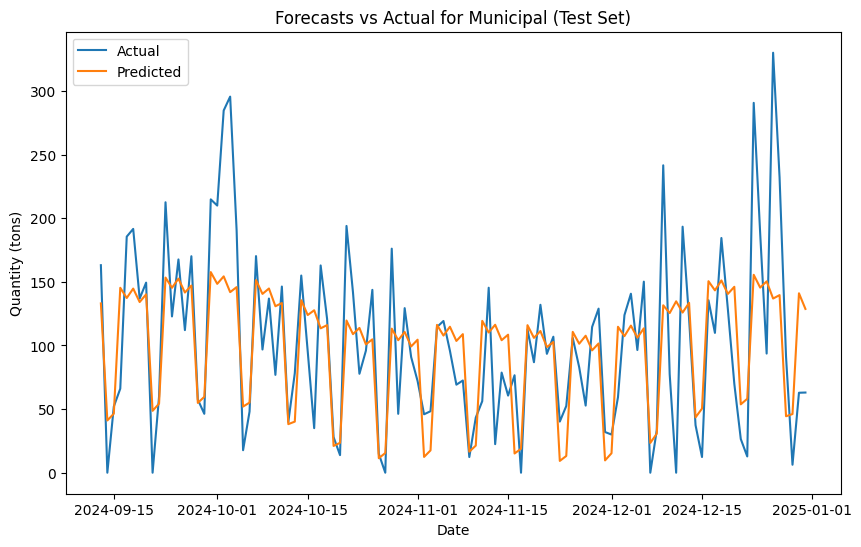

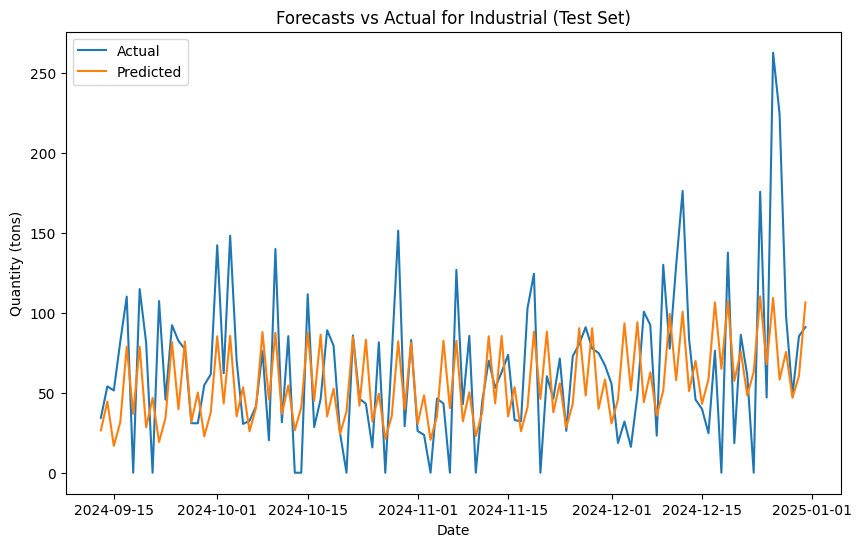

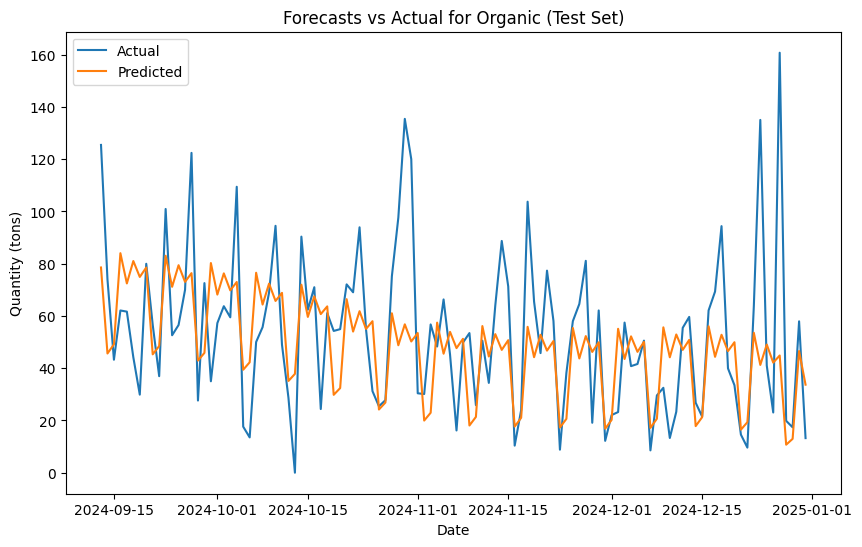

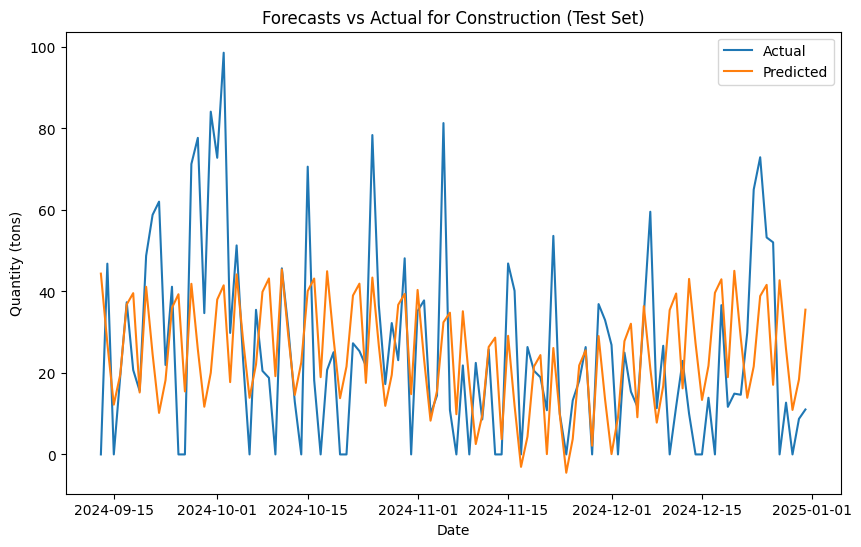

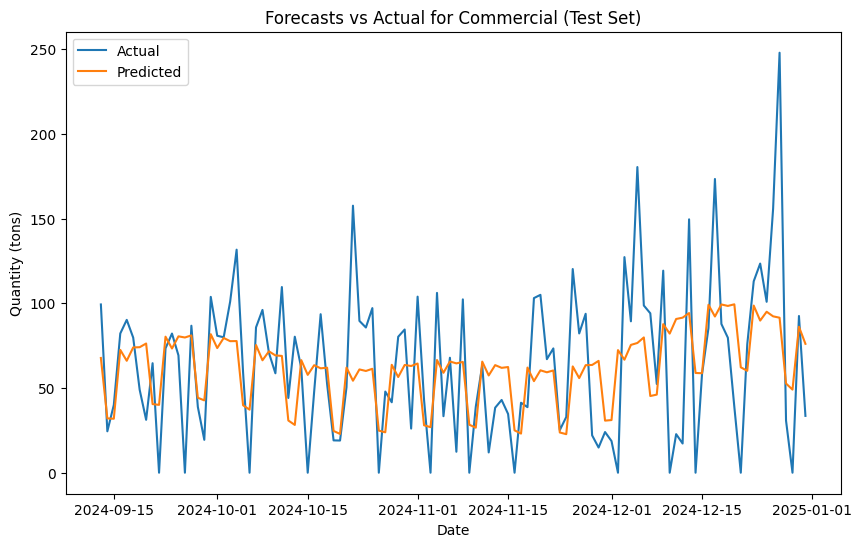

In [26]:
for waste, forecast in waste_quantity_forecasts.items():
    # Get the actual values for the test period
    test_actual = waste_dfs[waste]['quantity_tons'].values[-len(test_data):]
    
    # Get the predicted values for the test period
    test_predicted = forecast['yhat'].values[-len(test_data):]
    
    # Get the dates for the test period
    test_dates = forecast['ds'].dt.to_pydatetime()[-len(test_data):]
    
    # Create a new figure and plot the actual and predicted values for the test set
    plt.figure(figsize=(10, 6))
    plt.plot(test_dates, test_actual, label='Actual')
    plt.plot(test_dates, test_predicted, label='Predicted')
    plt.xlabel('Date')
    plt.ylabel('Quantity (tons)')
    plt.title(f"Forecasts vs Actual for {waste} (Test Set)")
    plt.legend()
    plt.show()

C:\Users\maxik\AppData\Local\Temp\ipykernel_13492\3623277114.py:12: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  test_dates = forecast['ds'].dt.to_pydatetime()[-len(test_data):]


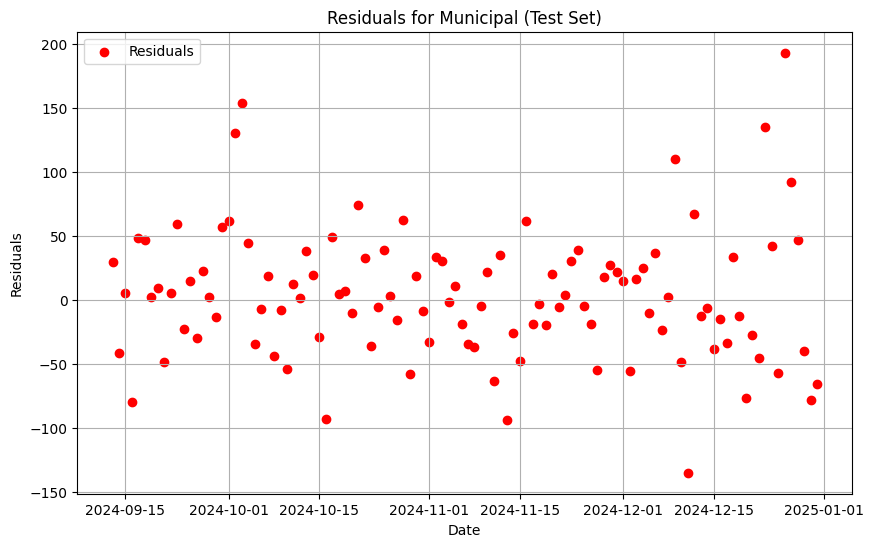

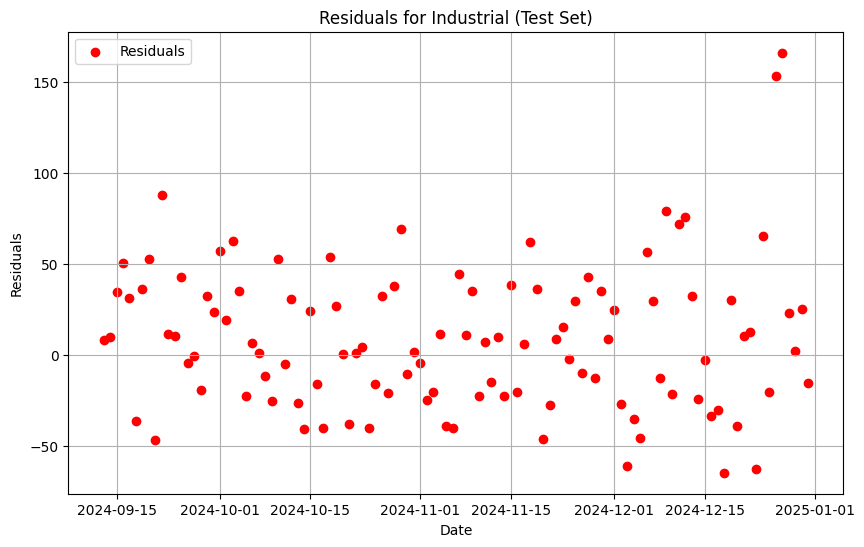

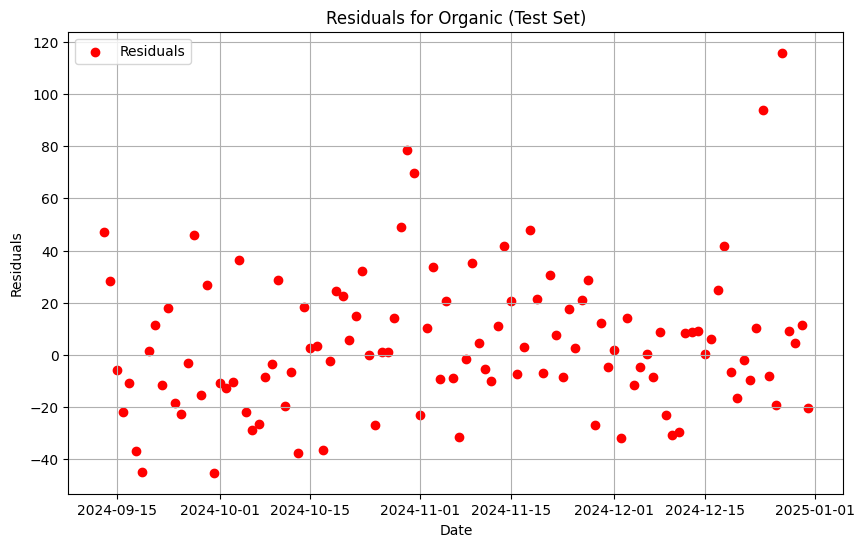

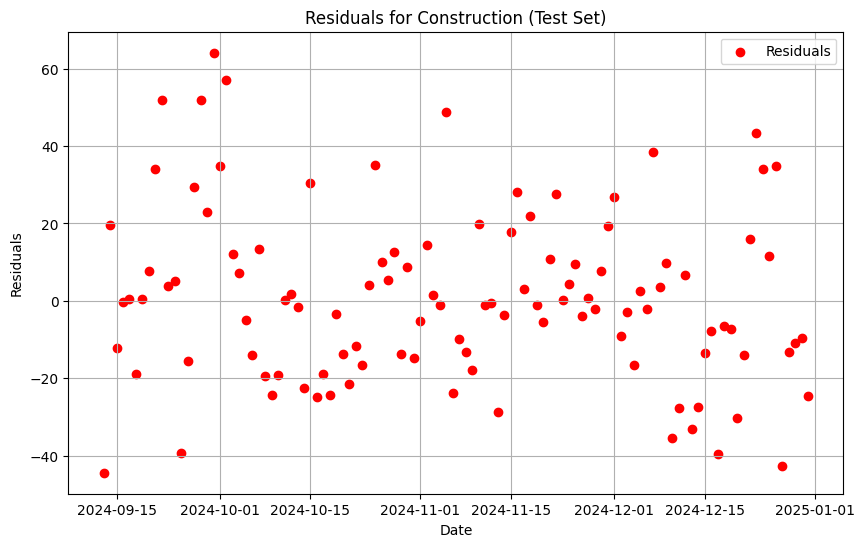

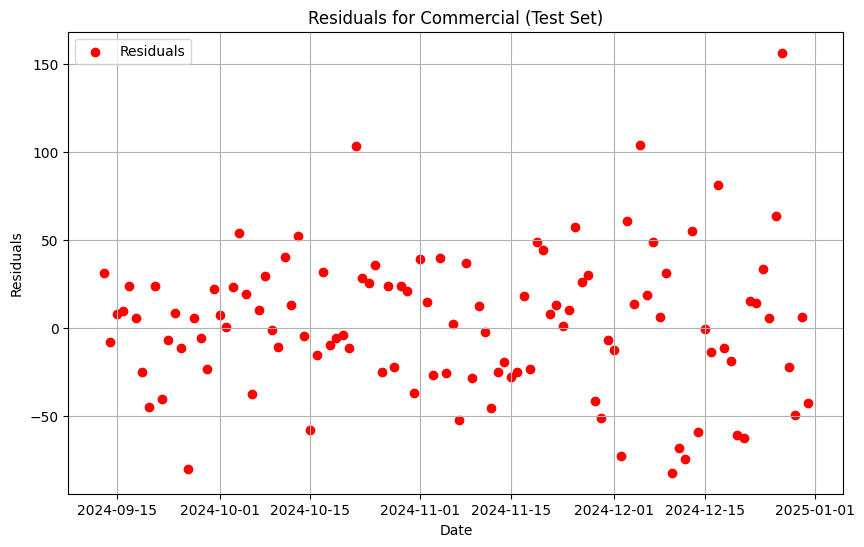

In [27]:
for waste, forecast in waste_quantity_forecasts.items():
    # Get the actual values for the test period
    test_actual = waste_dfs[waste]['quantity_tons'].values[-len(test_data):]
    
    # Get the predicted values for the test period
    test_predicted = forecast['yhat'].values[-len(test_data):]
    
    # Calculate the residuals
    residuals = test_actual - test_predicted
    
    # Get the dates for the test period
    test_dates = forecast['ds'].dt.to_pydatetime()[-len(test_data):]
    
    # Create a new figure for the residuals
    plt.figure(figsize=(10, 6))
    plt.scatter(test_dates, residuals, color='red', label='Residuals')
    plt.xlabel('Date')
    plt.ylabel('Residuals')
    plt.title(f"Residuals for {waste} (Test Set)")
    plt.legend()
    plt.grid(True)
    plt.show()

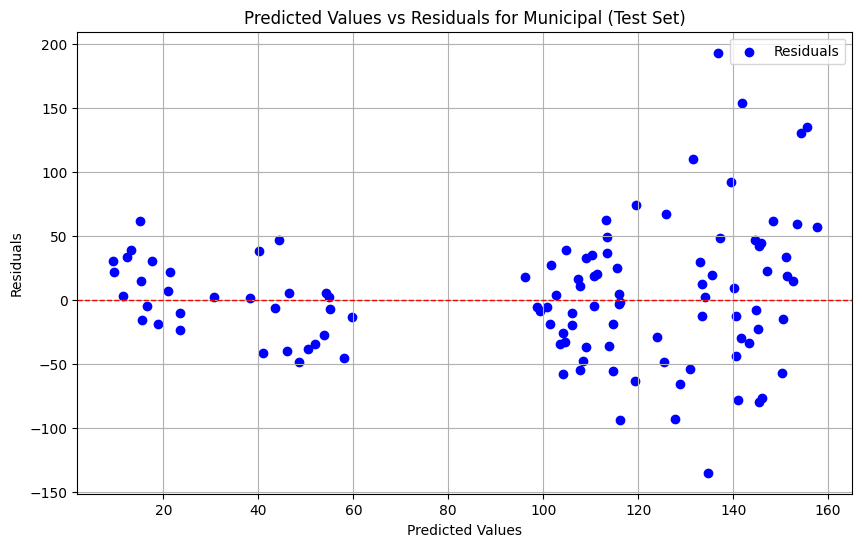

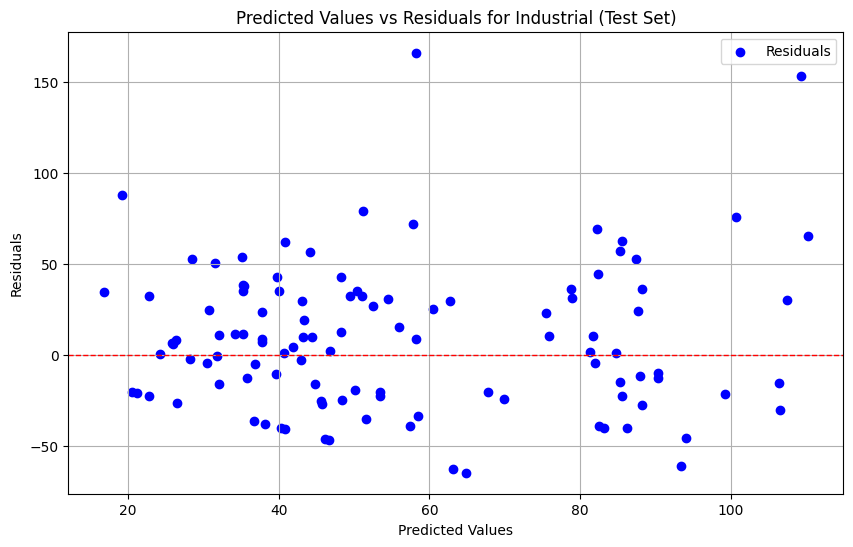

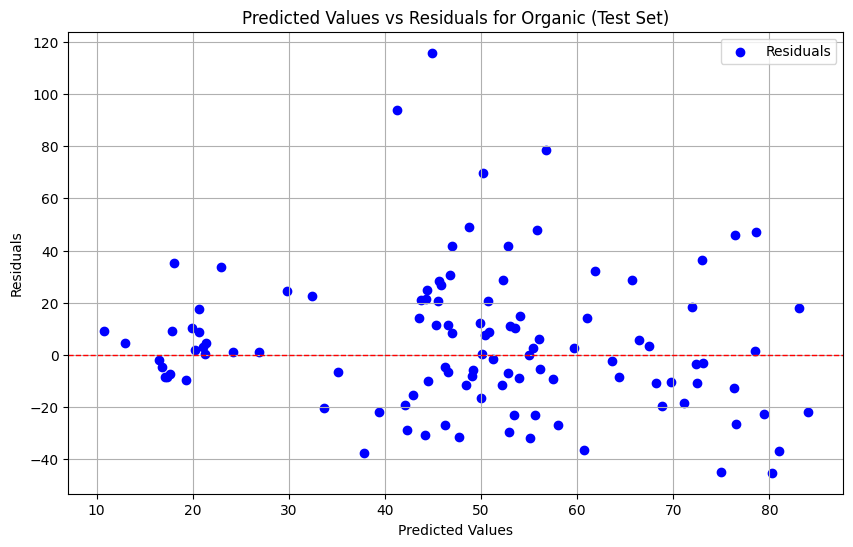

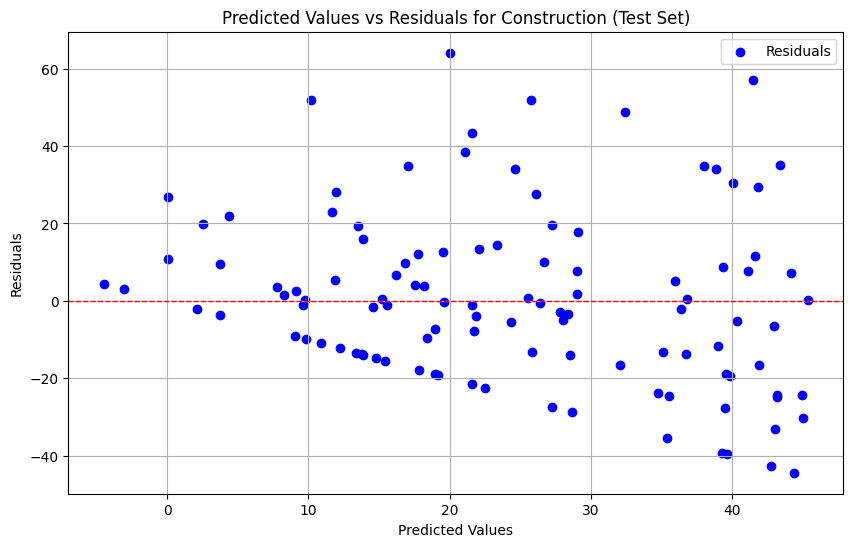

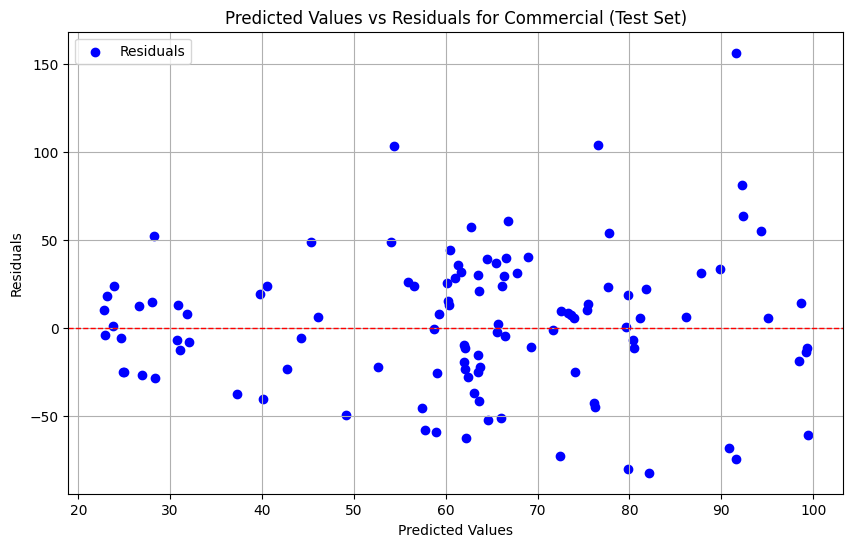

In [28]:
for waste, forecast in waste_quantity_forecasts.items():
    # Get the actual values for the test period
    test_actual = waste_dfs[waste]['quantity_tons'].values[-len(test_data):]
    
    # Get the predicted values for the test period
    test_predicted = forecast['yhat'].values[-len(test_data):]
    
    # Calculate the residuals
    residuals = test_actual - test_predicted
    
    # Create a new figure for the predicted values vs residuals
    plt.figure(figsize=(10, 6))
    plt.scatter(test_predicted, residuals, color='blue', label='Residuals')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title(f"Predicted Values vs Residuals for {waste} (Test Set)")
    plt.legend()
    plt.grid(True)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
    
    plt.show()